# Flight Fare Prediction using Machine Learning

## Problem Statement

The objective of this project is to predict airline ticket prices using historical flight information such as airline, source, destination, duration, and number of stops.

Accurate fare prediction can assist travelers in making informed booking decisions and help businesses analyze pricing trends.

In [1]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download(
    "nikhilmittal/flight-fare-prediction-mh"
)

df = pd.read_excel(
    os.path.join(path, "Data_Train.xlsx")
)

df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [2]:
df.shape

(10683, 11)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [4]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [5]:
df.isnull().sum()
# (df.isnull().sum()/len(df))*100

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

<Axes: >

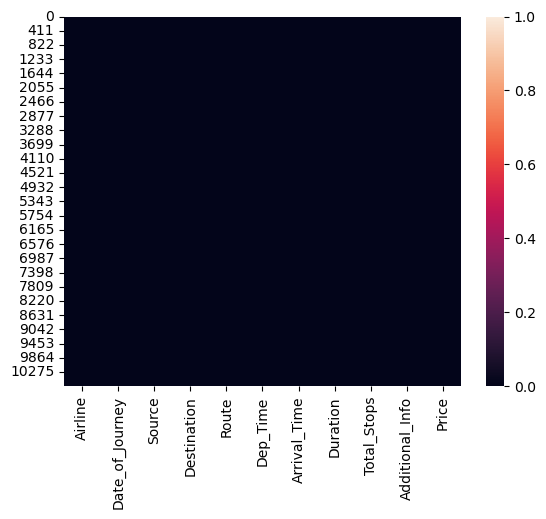

In [6]:
import seaborn as sns
sns.heatmap(df.isnull())

In [7]:
print(df.duplicated().sum(),"\n\n")
df[df.duplicated()].sample(1)

220 




,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
7088,Jet Airways,9/05/2019,Delhi,Cochin,DEL → JAI → BOM → COK,09:40,04:25 10 May,18h 45m,2 stops,In-flight meal not included,13029


In [8]:
df.drop_duplicates(inplace = True)
df.duplicated().sum()

0

In [9]:
df_Airline = df.groupby('Airline')['Price'].mean().sort_values()
df_Airline

Airline
Trujet                                4140.000000
SpiceJet                              4335.841718
Air Asia                              5590.260188
IndiGo                                5668.469897
GoAir                                 5861.056701
Vistara                               7801.355649
Vistara Premium economy               8962.333333
Air India                             9555.382891
Multiple carriers                    10902.678094
Multiple carriers Premium economy    11418.846154
Jet Airways                          11599.021081
Jet Airways Business                 58358.666667
Name: Price, dtype: float64

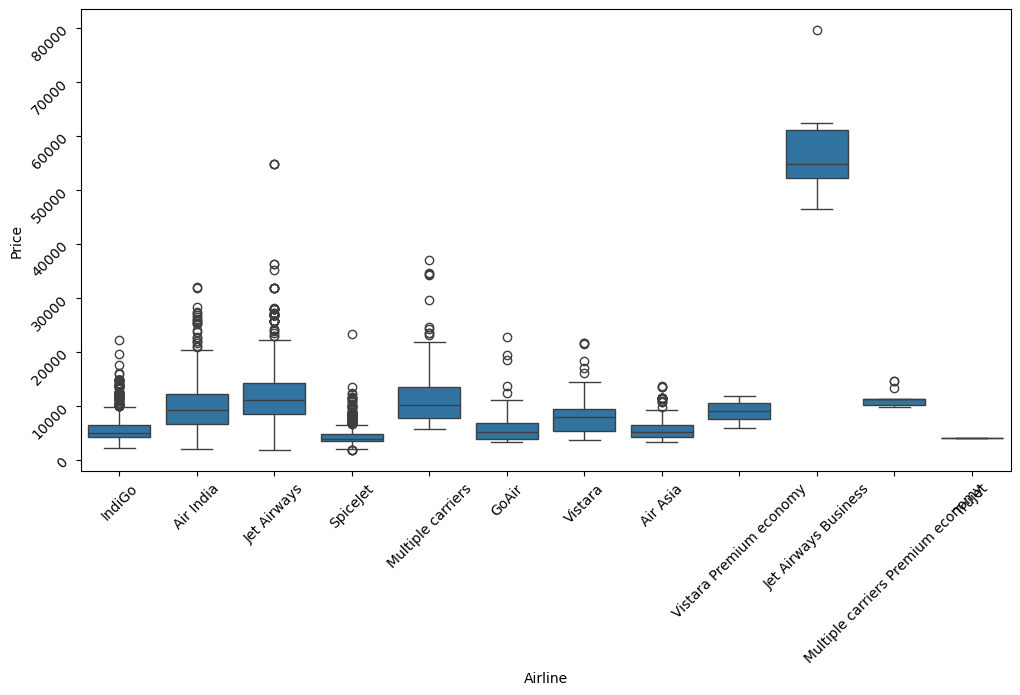

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(x='Airline', y='Price', data=df)
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

####  **Jet Airways Business has the highest fares.**
####  **IndiGo tends to be cheaper.**

In [12]:
df.groupby('Source')['Price'].mean().sort_values()

Source
Chennai      4789.892388
Mumbai       5059.708752
Banglore     8022.872877
Kolkata      9143.083566
Delhi       10460.914634
Name: Price, dtype: float64

<Axes: xlabel='Source', ylabel='Price'>

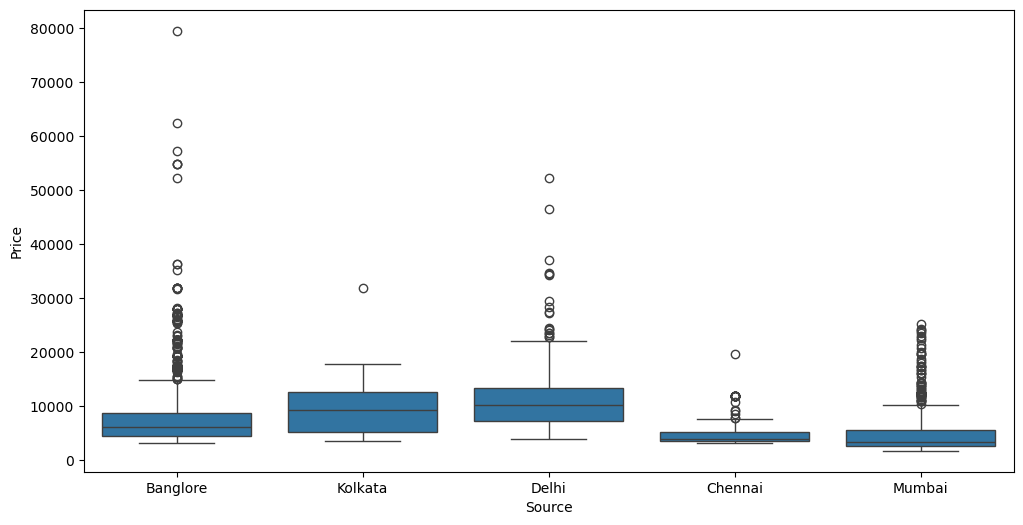

In [13]:
plt.figure(figsize=(12,6))
sns.boxplot(x = 'Source', y = 'Price', data = df)


#### **Flights originating from Delhi have higher average fares.**

In [15]:
df.groupby('Destination')['Price'].mean().sort_values()

Destination
Kolkata       4789.892388
Hyderabad     5059.708752
Delhi         5143.918577
Banglore      9143.083566
Cochin       10460.914634
New Delhi    12007.421225
Name: Price, dtype: float64

<Axes: xlabel='Destination', ylabel='Price'>

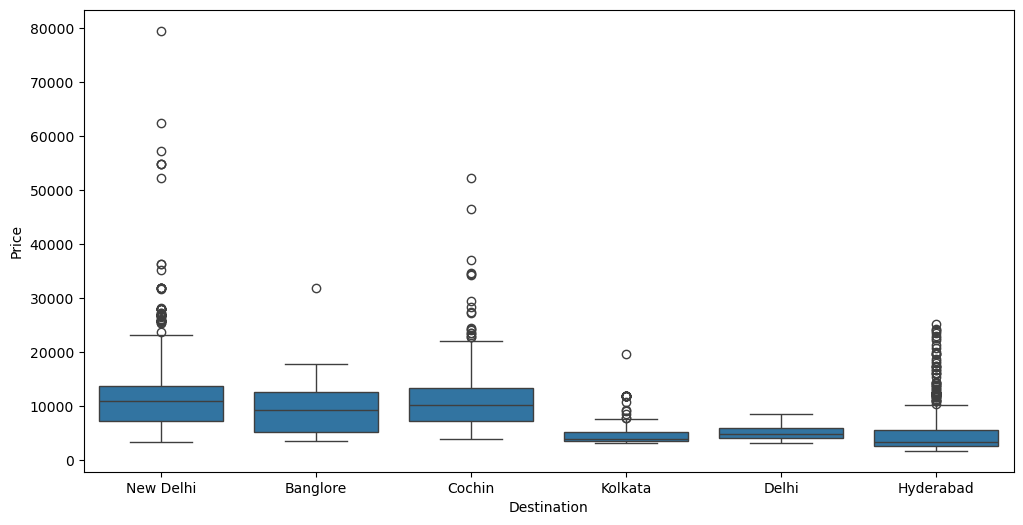

In [16]:
plt.figure(figsize=(12,6))
sns.boxplot(x = 'Destination', y = 'Price', data = df)

#### **The fights whose destination is to New Delhi have higher fares**

In [18]:
df[df['Price'] > 23022.75].shape

(94, 11)

In [19]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


### **Feature Engineering**

In [21]:
import numpy as np
df['Total_Stops'] = df['Total_Stops'].map({'non-stop':0, '2 stops':2, '1 stop':1, '3 stops':3, '4 stops':4,np.NaN: 1})

In [22]:
df['Total_Stops'].isnull().sum()

0

In [23]:
df.drop('Route',axis = 1,inplace = True)

In [24]:
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y')
df['Date_of_Journey']

0       2019-03-24
1       2019-05-01
2       2019-06-09
3       2019-05-12
4       2019-03-01
           ...    
10678   2019-04-09
10679   2019-04-27
10680   2019-04-27
10681   2019-03-01
10682   2019-05-09
Name: Date_of_Journey, Length: 10463, dtype: datetime64[ns]

In [25]:
df['Journey_day'] = df['Date_of_Journey'].dt.day   # df['Journey_day'] = df['Date_of_Journey'].str.split('/').str[0]
df['Journey_month'] = df['Date_of_Journey'].dt.month # df['Journey_month'] = df['Date_of_Journey'].str.split('/').str[1]
df.drop('Date_of_Journey',axis = 1,inplace = True)

In [26]:
df['Dep_Time'] = pd.to_datetime(df['Dep_Time'])
df['Dep_Hour'] = df['Dep_Time'].dt.hour
df['Dep_Minute'] = df['Dep_Time'].dt.minute
df.drop('Dep_Time',axis = 1,inplace = True)

C:\Users\ksidd\AppData\Local\Temp\ipykernel_16104\1803557974.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dep_Time'] = pd.to_datetime(df['Dep_Time'])


In [27]:
df['Arrival_Time'] = pd.to_datetime(df['Arrival_Time'])  #df['Arrival_Time'] = df['Arrival_Time'].apply(lambda x:x.split(' ')[0])
df['Arrival_Hour'] = df['Arrival_Time'].dt.hour          #df['Arrival_Hour'] = df['Arrival_Time'].str.split(':').str[0]
df['Arrival_Minute'] = df['Arrival_Time'].dt.minute      #df['Arrival_Minute'] = df['Arrival_Time'].str.split(':').str[1]
df.drop('Arrival_Time',axis = 1,inplace = True)

C:\Users\ksidd\AppData\Local\Temp\ipykernel_16104\195828951.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Arrival_Time'] = pd.to_datetime(df['Arrival_Time'])  #df['Arrival_Time'] = df['Arrival_Time'].apply(lambda x:x.split(' ')[0])


In [28]:
df.head()

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute
0,IndiGo,Banglore,New Delhi,2h 50m,0,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,7h 25m,2,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,19h,2,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,5h 25m,1,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,4h 45m,1,No info,13302,1,3,16,50,21,35


#### **Encoding**

In [30]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()

In [31]:
encoded = encoder.fit_transform(df[['Airline','Source','Destination']]).toarray()
encoded.astype('int8')

array([[0, 0, 0, ..., 0, 0, 1],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 1, 0, ..., 0, 0, 0]], dtype=int8)

In [32]:
encoded_df = pd.DataFrame(encoded,columns = encoder.get_feature_names_out(),dtype = 'int8')
encoded_df

,Airline_Air Asia,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,...,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,1,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10458,1,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
10459,0,1,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
10460,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
10461,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [33]:
import pandas as pd
df = pd.concat([df,encoded_df],axis = 1)
df.drop('Airline',axis = 1,inplace = True)

#### **Statistical Analysis**

In [35]:
import numpy as np
Minimum,Q1,Median,Q3,Maximum =np.percentile(df['Price'],[0,25,50,75,100])
Minimum,Q1,Median,Q3,Maximum

(nan, nan, nan, nan, nan)

In [36]:
IQR = Q3-Q1
lower_fence = Q1-1.5*(IQR)
upper_fence = Q3+1.5*(IQR)
lower_fence,upper_fence

(nan, nan)

<Axes: ylabel='Price'>

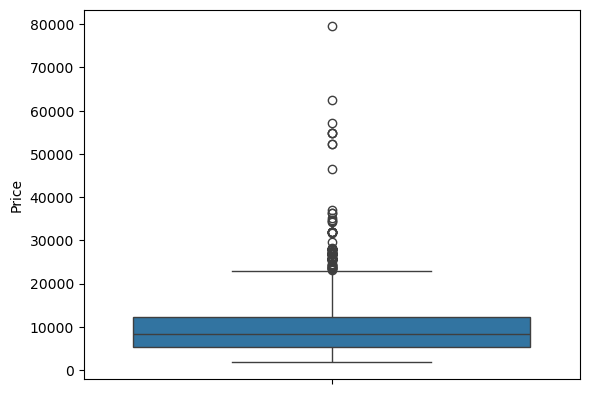

In [37]:
sns.boxplot(y = 'Price', data = df)

<Axes: xlabel='Price', ylabel='Count'>

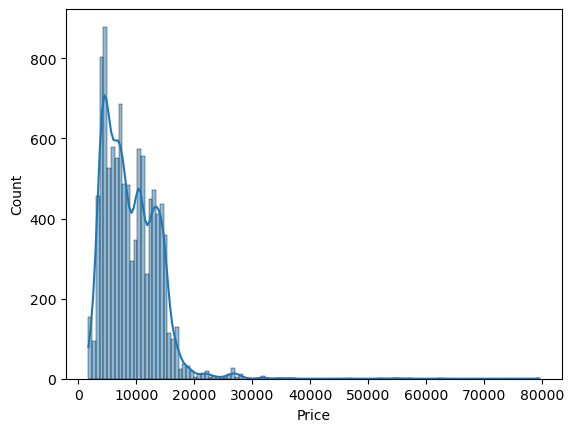

In [38]:
sns.histplot(df['Price'],kde = True)

In [39]:
df.columns

Index(['Source', 'Destination', 'Duration', 'Total_Stops', 'Additional_Info',
       'Price', 'Journey_day', 'Journey_month', 'Dep_Hour', 'Dep_Minute',
       'Arrival_Hour', 'Arrival_Minute', 'Airline_Air Asia',
       'Airline_Air India', 'Airline_GoAir', 'Airline_IndiGo',
       'Airline_Jet Airways', 'Airline_Jet Airways Business',
       'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy',
       'Source_Banglore', 'Source_Chennai', 'Source_Delhi', 'Source_Kolkata',
       'Source_Mumbai', 'Destination_Banglore', 'Destination_Cochin',
       'Destination_Delhi', 'Destination_Hyderabad', 'Destination_Kolkata',
       'Destination_New Delhi'],
      dtype='object')

In [40]:
def Duration_Minutes(Duration):
    hours = 0
    minutes = 0

    Duration = str(Duration)
    if 'h' in Duration:
        hours = int(Duration.split('h')[0])
    elif 'm' in Duration:
        minute_part = Duration.split('h')[-1].replace('m',' ').strip()
        if minute_part:
            minutes = int(minute_part)
    return hours*60 + minutes

df['Duration_Minutes'] = df['Duration'].apply(Duration_Minutes)

In [41]:
df[['Duration_Minutes','Price']].corr()

,Duration_Minutes,Price
Duration_Minutes,1.000000,0.504093
Price,0.504093,1.000000


#### **There is a moderate positive correlation (0.51) between flight duration and price.**

#### **Longer flights generally have higher prices**
#### **Flight duration does influence the ticket price**

<Axes: xlabel='Duration_Minutes', ylabel='Price'>

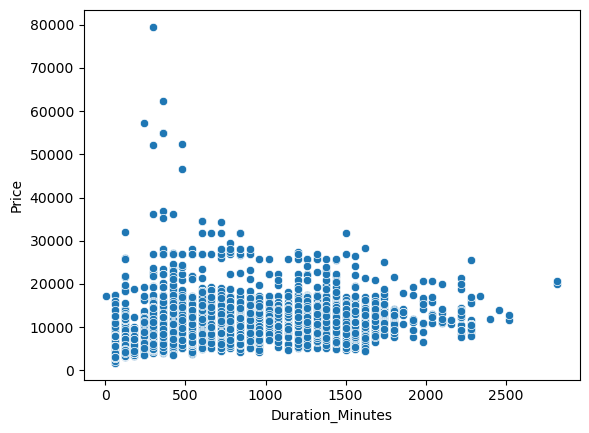

In [43]:
sns.scatterplot(x = 'Duration_Minutes',y = 'Price', data = df)

In [44]:
df.drop(['Source','Destination','Duration','Additional_Info'],axis = 1,inplace =True)

In [45]:
df = df.dropna(subset=['Price'])

In [46]:
dummy_cols = [
    col for col in df.columns
    if col.startswith('Airline_')
    or col.startswith('Source_')
    or col.startswith('Destination_')
]

df[dummy_cols] = df[dummy_cols].fillna(0)

In [47]:
df.isnull().sum()

Total_Stops                                  0
Price                                        0
Journey_day                                  0
Journey_month                                0
Dep_Hour                                     0
Dep_Minute                                   0
Arrival_Hour                                 0
Arrival_Minute                               0
Airline_Air Asia                             0
Airline_Air India                            0
Airline_GoAir                                0
Airline_IndiGo                               0
Airline_Jet Airways                          0
Airline_Jet Airways Business                 0
Airline_Multiple carriers                    0
Airline_Multiple carriers Premium economy    0
Airline_SpiceJet                             0
Airline_Trujet                               0
Airline_Vistara                              0
Airline_Vistara Premium economy              0
Source_Banglore                              0
Source_Chenna

In [48]:
X = df.drop('Price',axis = 1)
y = df['Price']

In [49]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

#### **Linear Regression**

In [51]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)
print(pred_lr)

[13039.31211511 13917.89710777  5254.31603232 ...  6547.98629781
  8474.04649083  8462.67249483]


#### **Model Evaluation Linear Regression**

In [53]:
from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error,
                             r2_score)

mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)
print(mae_lr,rmse_lr,r2_lr)

2437.721225809169 3441.981519285243 0.4321873578589518


#### **DecisionTreeRegressor**

In [55]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)
print(pred_dt,"\n")

[13076.796875   12980.60465116  3943.         ...  5313.33333333
 11144.77165354  9331.65116279] 



#### **Model Evaluation Decision Tree**

In [57]:
mae_dt = mean_absolute_error(y_test, pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, pred_dt))
r2_dt = r2_score(y_test, pred_dt)
print(mae_dt,rmse_dt,r2_dt)

1611.7606049134768 2725.3853290488764 0.6440050667603314


#### **RandomForestRegressor**

In [59]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)
print(pred_rf)

[13457.335 10296.76   4079.45  ...  5319.    10740.86   6937.09 ]


#### **Model Evaluation Random Forest**

In [61]:
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)
print(mae_rf,rmse_rf,r2_rf)

1340.3526747861351 2182.5861207030716 0.7716869332372214


#### **Hyperparameter Tuning**

##### **Tuning Decison Tree**

In [64]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

param_dist = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None]
}

random_dt = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_dt.fit(X_train, y_train)

print("Best Parameters:", random_dt.best_params_)
print("Best CV Score:", random_dt.best_score_)

Best Parameters: {'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': None}
Best CV Score: 0.7100183113714686


##### **Tuning Random Forest**

In [66]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

random_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_rf.fit(X_train, y_train)
# pred_rf_tuned = random_rf.predict(X_test)
print("Best Parameters:", random_rf.best_params_)
print("Best CV Score:", random_rf.best_score_)

Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Best CV Score: 0.6839799361018744


In [67]:
best_rf = random_rf.best_estimator_
pred_best_rf = best_rf.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, pred_best_rf)
rmse = np.sqrt(mean_squared_error(y_test, pred_best_rf))
r2 = r2_score(y_test, pred_best_rf)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 1665.7010195681391
RMSE: 2457.770137177942
R2  : 0.710485369499796


In [68]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "R2 Score": [
        r2_lr,
        r2_dt,
        r2_rf,
        r2
    ]
})

results.sort_values(by=["R2 Score"], ascending=False)

,Model,R2 Score
2,Random Forest,0.771687
3,Tuned Random Forest,0.710485
1,Decision Tree,0.644005
0,Linear Regression,0.432187


In [69]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)
pred_xgb

array([13097.681 , 12551.469 ,  4185.7334, ...,  4638.0425, 10484.254 ,
        7971.3325], dtype=float32)

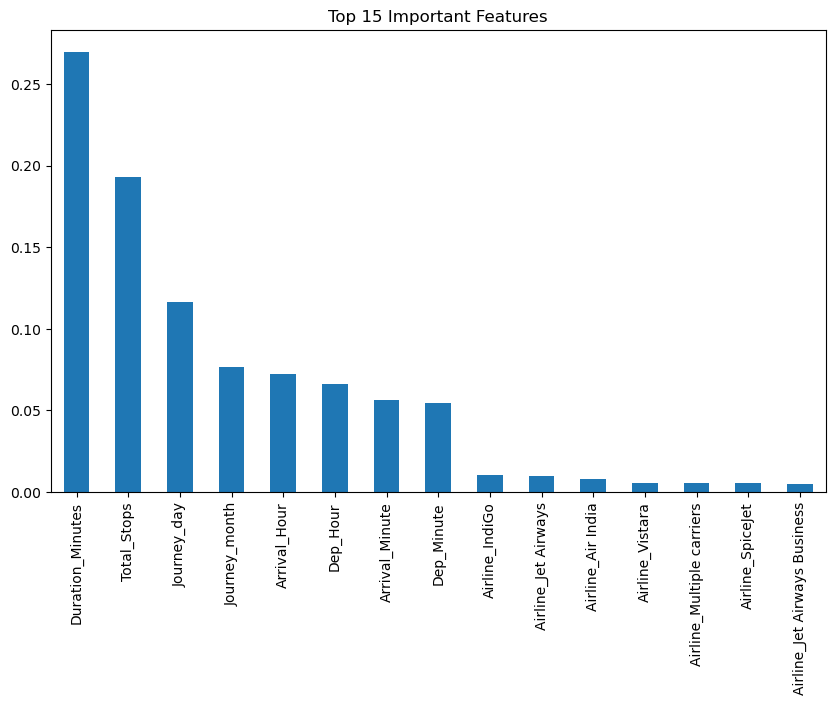

In [70]:
import matplotlib.pyplot as plt

importance = best_rf.feature_importances_

feat_imp = pd.Series(
    importance,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(15).plot(kind='bar')
plt.title("Top 15 Important Features")
plt.show()

In [71]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(scores.mean())

0.7607290384125359


In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

models = {
    "Linear Regression": pred_lr,
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf,
    "Tuned Random Forest": pred_best_rf,
    "XGBoost": pred_xgb
}

results = []

for model_name, predictions in models.items():

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    results.append([model_name, mae, rmse, r2])

comparison_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R² Score"]
)

comparison_df = comparison_df.sort_values(
    by="R² Score",
    ascending=False
)

comparison_df

,Model,MAE,RMSE,R² Score
2,Random Forest,1340.352675,2182.586121,0.771687
4,XGBoost,1426.037228,2240.468947,0.759416
3,Tuned Random Forest,1665.701020,2457.770137,0.710485
1,Decision Tree,1611.760605,2725.385329,0.644005
0,Linear Regression,2437.721226,3441.981519,0.432187


##### **Actual vs Predicted**

##### **It compares the actual flight prices with the prices predicted by the XGBoost model**

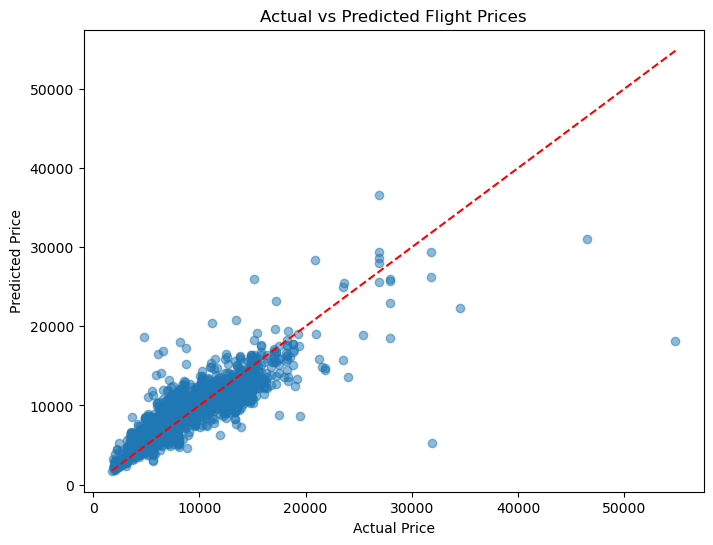

In [130]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, pred_xgb, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Flight Prices")

plt.show()

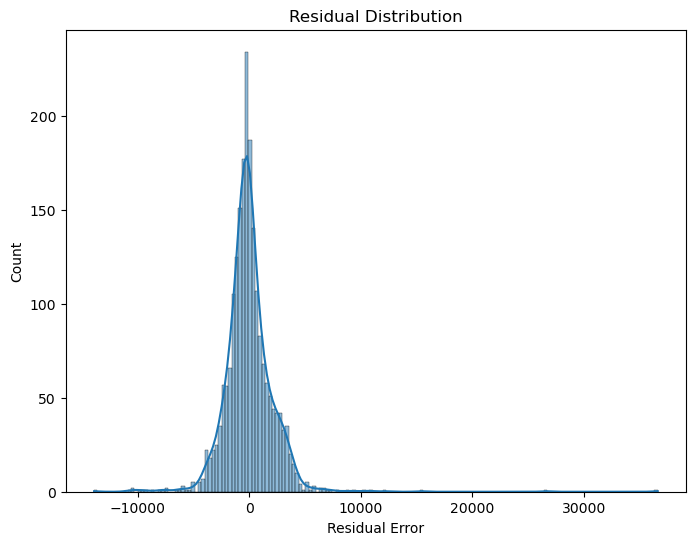

In [135]:
# Residual Analysis

residuals = y_test - pred_xgb

plt.figure(figsize=(8,6))

sns.histplot(residuals, kde=True)

plt.xlabel("Residual Error")
plt.title("Residual Distribution")

plt.show()

##### **Conclusion**

In [ ]:
This project developed an end-to-end machine learning pipeline for predicting airline ticket prices.

The workflow included:

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- One-Hot Encoding
- Model Training
- Hyperparameter Tuning
- Cross Validation
- Model Evaluation

The following models were evaluated:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. Tuned Random Forest Regressor
5. XGBoost Regressor

Among all models, XGBoost achieved the best performance based on R² Score, MAE, and RMSE metrics.
